In [1]:
setwd('/home/rstudio/analysis/')

In [2]:
library(Seurat)
library(ggplot2)
library(sctransform)
library(scRepertoire)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [3]:
# importing patient3, doing SCTransform, filtering mitochondrial content

In [4]:
patient3.data <- Read10X(data.dir = "/home/rstudio/run070/run070-nsclc-3_RSEC_MolsPerCell_MEX")
patient3 <- CreateSeuratObject(counts = patient3.data, project = "patient3", min.cells = 3, min.features = 200)

patient3[["percent.mt"]] <- PercentageFeatureSet(patient3, pattern = "^MT-")

patient3_transform <- SCTransform(patient3, verbose = FALSE)

patient3_transform <- subset(patient3_transform, subset = percent.mt < 20)

In [5]:
# importing patient4, doing SCTransform, filtering mitochondrial content

In [6]:
patient4.data <- Read10X(data.dir = "/home/rstudio/run071/run071_RSEC_MolsPerCell_MEX")
patient4 <- CreateSeuratObject(counts = patient4.data, project = "patient4", min.cells = 3, min.features = 200)

patient4[["percent.mt"]] <- PercentageFeatureSet(patient4, pattern = "^MT-")

patient4_transform <- SCTransform(patient4, verbose = FALSE)

patient4_transform <- subset(patient4_transform, subset = percent.mt < 20)

In [7]:
merged_seurat <- merge(patient3_transform, patient4_transform)

In [8]:
install.packages('BiocManager')
BiocManager::install('glmGamPoi')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://p3m.dev/cran/__linux__/noble/2025-02-27

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'glmGamPoi'”
Old packages: 'BiocParallel', 'curl', 'data.table', 'DOSE', 'ggnewscale',
  'jsonlite', 'processx', 'ps', 'R.utils', 'reticulate', 'tinytex', 'uwot',
  'VGAM', 'xfun', 'zoo'



In [9]:
merged_seurat <- SCTransform(merged_seurat, verbose = FALSE)

Warning message:
“Different cells and/or features from existing assay SCT”


In [10]:
merged_seurat <- FindVariableFeatures(merged_seurat, assay = "RNA")
merged_seurat <- NormalizeData(merged_seurat, assay = "RNA")
merged_seurat <- ScaleData(merged_seurat, assay = "RNA")

Finding variable features for layer counts.patient3

Finding variable features for layer counts.patient4

Normalizing layer: counts.patient3

Normalizing layer: counts.patient4

Centering and scaling data matrix



In [11]:
merged_seurat <- RunPCA(merged_seurat, assay = "RNA", reduction.name = "pca.rna")

PC_ 1 
Positive:  IL7R, KLF2, FTH1, SELL, SATB1, ANXA1, FOS, S1PR1, SESN3, LNCRNA-IUR 
	   MT-CO3, RPS2, YBX3, ZBTB16, SNED1, RPS18, GPCPD1, IRS2, GPR183, KRT1 
	   RNF130, ACTN1, BACH2, ARL4C, MBP, KCNA3, ABLIM1, ZHX2, SCML1, MT-CO1 
Negative:  TYMS, DUSP4, MKI67, HLA-DRB1, RRM2, TOP2A, CXCL13, HLA-DRA, NCAPG, CENPU 
	   MYO7A, RBPJ, ASPM, TPX2, KIF11, CCNA2, ITGAE, GZMB, STMN1, CDK1 
	   CTLA4, HLA-DRB6, APOBEC3C, UBE2C, CD74, HSPA1A, HMGB2, CCL5, PMAIP1, NKG7 
PC_ 2 
Positive:  DUSP4, CCL5, MYO7A, TNFRSF9, CBLB, ITGAE, LYST, NKG7, CXCL13, KRT86 
	   AKAP5, LAYN, RGS1, HSPA1A, ETV1, PRDM1, VCAM1, RBPJ, CXCR6, GZMB 
	   CTLA4, HAVCR2, ADGRG1, TOX, HLA-DRB1, IKZF3, PRF1, RDH10, GOLIM4, DTHD1 
Negative:  RRM2, MKI67, TYMS, TOP2A, NCAPG, TUBB, UBE2C, ZWINT, CDCA5, CDK1 
	   CENPU, IL7R, BIRC5, KIF18B, KIF11, STMN1, PCLAF, ASPM, SELL, ASF1B 
	   FTH1, KLF2, CDKN3, UHRF1, CCNA2, KIFC1, RAD51, PRR11, VIM, MT-CO3 
PC_ 3 
Positive:  NR4A1, FOSB, HSPA1A, NR4A2, HSPA8, DNAJB1, EGR1, KLF6, ID2, 

In [12]:
merged_seurat <- IntegrateLayers(
  object = merged_seurat,
  method = RPCAIntegration,
  orig.reduction = "pca.rna",
  new.reduction = "integrated.rpca",
  verbose = TRUE,
  layers = c("counts.patient3", "counts.patient4"),
  assay = "RNA"
)

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 347 anchors

Merging dataset 2 into 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data



In [13]:
merged_seurat <- RunPCA(merged_seurat)
merged_seurat <- RunUMAP(merged_seurat, dims = 1:30)
merged_seurat <- FindNeighbors(merged_seurat, dims = 1:30)
merged_seurat <- FindClusters(merged_seurat, resolution = 0.5)
merged_seurat <- FindClusters(merged_seurat, resolution = 0.8)
merged_seurat <- FindClusters(merged_seurat, resolution = 1.2)

Warning message in PrepDR(object = object, features = features, verbose = verbose):
“The following 28 features requested have not been scaled (running reduction without them): CXCL8, LYZ, IL1B, CXCL2, FCN1, MARCKS, CXCL3, SERPINB2, S100A8, EREG, G0S2, KIR2DL1, MAFB, LILRB2, CYBB, KRT72, KIR2DS4, PPP1R2C, SERPINA1, ZBED3, XIST, TRDC, FPR1, DDX3Y, PLS3, TNFAIP2, MPEG1, SPI1”
PC_ 1 
Positive:  DUSP4, HSPA1A, CXCL13, HLA-DRB1, CCL5, CD74, HSP90AA1, RBPJ, RGS1, PMAIP1 
	   CRTAM, MYO7A, CCL4, HLA-DRA, HSPA1B, GZMB, NKG7, PRDM1, ITGAE, CBLB 
	   TNFRSF9, VCAM1, KRT86, LYST, GLCCI1, CTLA4, TOX, HLA-DRB6, TUBB, IKZF3 
Negative:  FTH1, EEF1A1, IL7R, PABPC1, RPL34, RPS6, TPT1, RPS18, RPS12, SELL 
	   RPS27, RPL21, RPS29, ANXA1, RPL3, RPS3A, RPS13, RPL32, RPS20, RPS8 
	   RPL39, KLF2, MT-ND2, RPS23, RPL13A, RPS27A, RPL9, RPL31, RPL10, RPS4X 
PC_ 2 
Positive:  TUBB, TYMS, STMN1, ACTB, RRM2, TUBA1B, HMGN2, MKI67, TOP2A, VIM 
	   HMGB2, ACTG1, HSPA1A, ASPM, CENPU, HLA-DRA, SMC4, PCNA, CCNA2, HSPA1B 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 6489
Number of edges: 250466

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8433
Number of communities: 9
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 6489
Number of edges: 250466

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7950
Number of communities: 10
Elapsed time: 0 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 6489
Number of edges: 250466

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7448
Number of communities: 14
Elapsed time: 0 seconds


In [14]:
#checking metadata
colnames(merged_seurat@meta.data)

[1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "percent.mt"     
 [5] "nCount_SCT"      "nFeature_SCT"    "SCT_snn_res.0.5" "seurat_clusters"
 [9] "SCT_snn_res.0.8" "SCT_snn_res.1.2"

### scRepertoire - patient 3 + patient 4

In [15]:
# import
library(scRepertoire)
S1 <- read.delim("/home/rstudio/run070/run070-nsclc-3_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

contig_list_1 <- list(S1)
contig_list_1 <- loadContigs(input = S1, 
                           format = "AIRR")

library(scRepertoire)
S2 <- read.delim("/home/rstudio/run071/run071-nsclc-4_VDJ_Dominant_Contigs_AIRR.tsv", sep = "\t", header = TRUE, stringsAsFactors = FALSE)

contig_list_2 <- list(S2)
contig_list_2 <- loadContigs(input = S2, 
                           format = "AIRR")

In [16]:
combined.TCR_all <- combineTCR(
  c(contig_list_1, contig_list_2),
  samples = c("P3_S1", "P4_S1"),
  removeNA = TRUE,
  removeMulti = FALSE,
  filterMulti = FALSE
)

### combineExpression()

In [17]:
#check
#head(combined.TCR_all[[1]]$barcode)
#head(combined.TCR_all[[2]]$barcode)
#combined.TCR_all

In [18]:
combined.TCR_all <- lapply(combined.TCR_all, function(x) {
  x$barcode <- gsub("^P[0-9]+_S[0-9]+_", "", x$barcode)
  return(x)
})

In [19]:
sce_all_patients_new <- combineExpression(
  combined.TCR_all,
  merged_seurat, 
  cloneCall = "CTgene", 
  group.by = "sample",
  proportion = TRUE,
  cloneSize = c(Single = 1, Small = 5, Medium = 20, Large = 100, Hyperexpanded = 500)
)

In [20]:
sce_all_patients_new

An object of class Seurat 
45180 features across 6489 samples within 2 assays 
Active assay: SCT (21306 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca.rna, integrated.rpca, pca, umap

In [21]:
colnames(sce_all_patients_new@meta.data)

[1] "orig.ident"       "nCount_RNA"       "nFeature_RNA"     "percent.mt"      
 [5] "nCount_SCT"       "nFeature_SCT"     "SCT_snn_res.0.5"  "seurat_clusters" 
 [9] "SCT_snn_res.0.8"  "SCT_snn_res.1.2"  "CTgene"           "CTnt"            
[13] "CTaa"             "CTstrict"         "clonalProportion" "clonalFrequency" 
[17] "cloneSize"

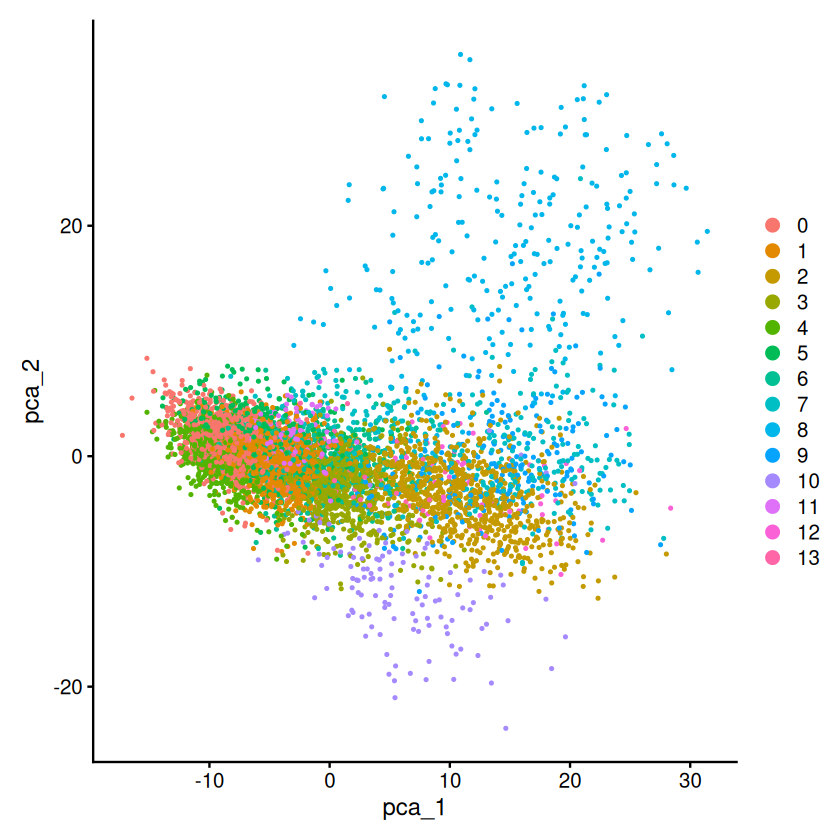

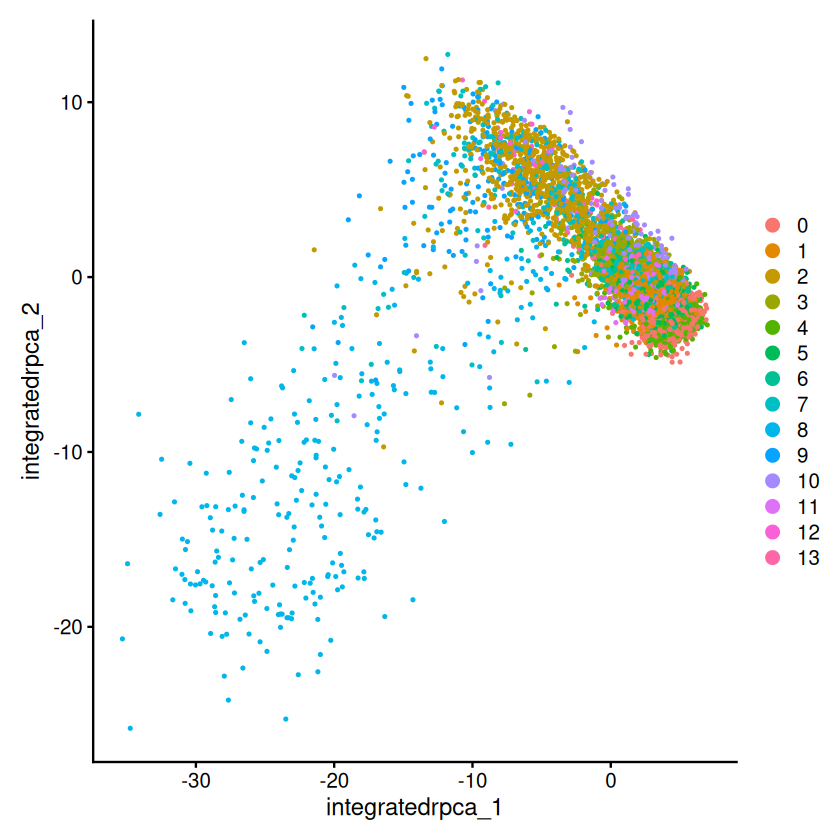

In [22]:
DimPlot(sce_all_patients_new, reduction = "pca") 
DimPlot(sce_all_patients_new, reduction = "integrated.rpca")

In [23]:
setwd('/home/rstudio/analysis/saved_objects_new')
getwd()

#export

saveRDS(merged_seurat, "merged_seurat.rds")
saveRDS(combined.TCR_all, "combined_TCR_all.rds")
saveRDS(sce_all_patients_new, "sce_all_patients_new.rds")

[1] "/home/rstudio/analysis/saved_objects_new"